In [ ]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

sc.set_figure_params(figsize=(5, 5))

In [ ]:
adata = sc.read_h5ad("./adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv("./MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

In [ ]:
f = h5py.File("./Bonsai_48h-1/bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords

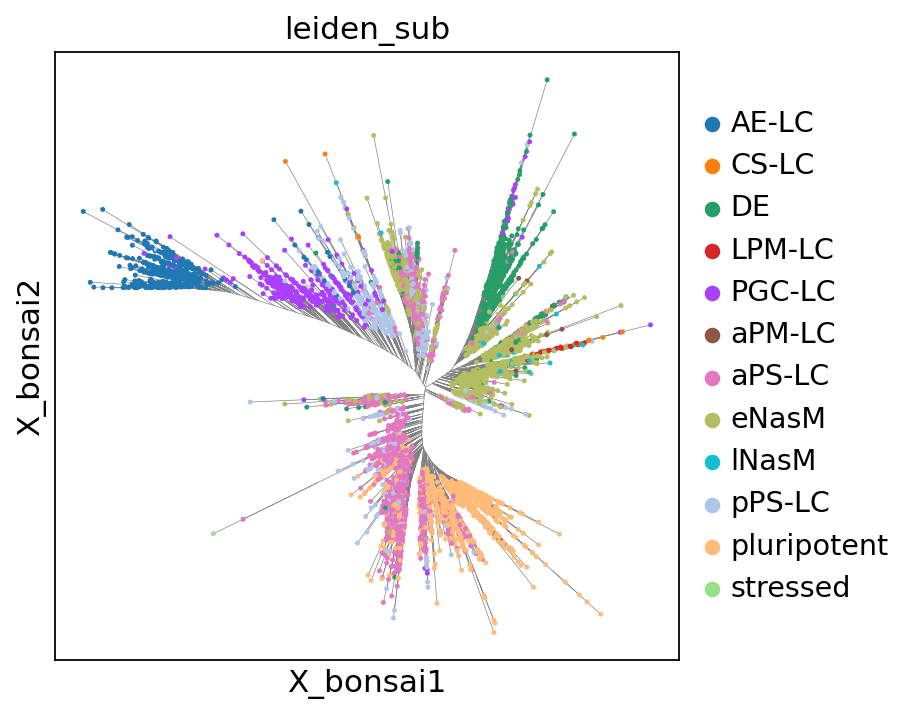

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
# optionally plot branch points
# ax.scatter(coords[int_inds, 0], coords[int_inds, 1], s=1, c="gray", alpha=0.5, zorder=2)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)
plt.savefig(
    "bonsai_micropattern_48h-1_circular_tree_view.png", dpi=300, bbox_inches="tight"
)

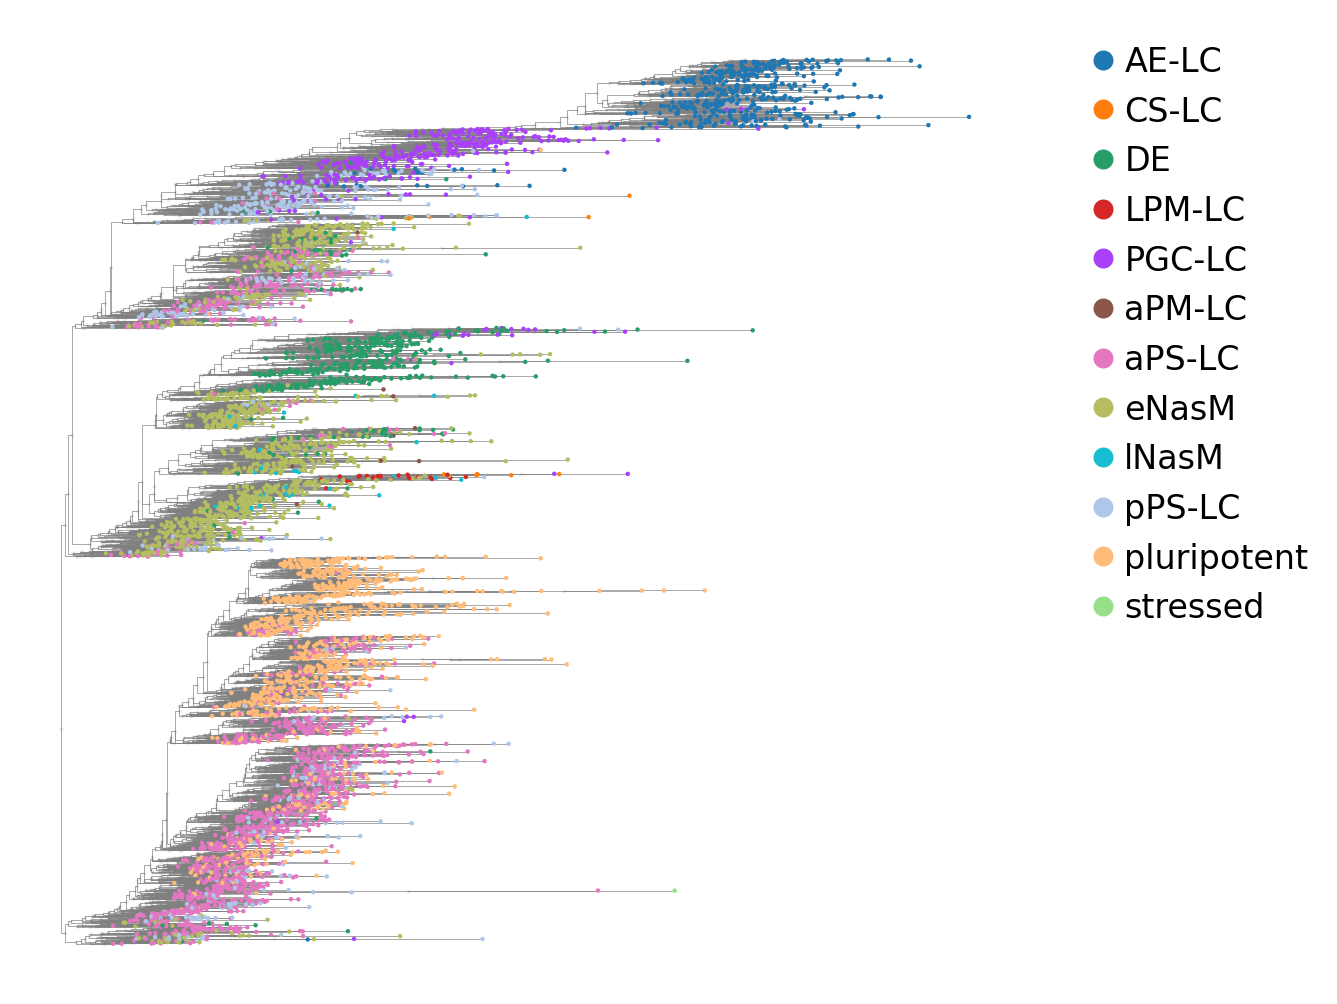

In [85]:
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
plt.savefig("bonsai_micropattern_48h-1_rec_tree_view.png", dpi=300, bbox_inches="tight")

In [ ]:
# for web app
# adata.obs.to_csv(
#     "./heemskerk_data/adata_timeseries_old_48h-1_meta.csv", index_label="cellID"
# )